# Лабораторная работа №1. Логическая классификация

В ноутбуке выполнен эксперимент для собственной реализации бинарного дерева ID3 с критерием Джини: загрузка датасета Titanic, обучение модели, редукция дерева, сравнение со sklearn и сохранение артефактов.

## 1. Подготовка окружения

Импортируем внешние библиотеки, добавляем папку `source` в `sys.path` и подключаем собственную реализацию дерева.

In [10]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

LAB_DIR = Path.cwd()
if not (LAB_DIR / "source").exists():
    repo_relative_lab_dir = Path("students/mukhomediarova-ar/lab1")
    if repo_relative_lab_dir.exists():
        LAB_DIR = repo_relative_lab_dir.resolve()

SOURCE_DIR = LAB_DIR / "source"
ARTIFACTS_DIR = LAB_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

if str(SOURCE_DIR) not in sys.path:
    sys.path.append(str(SOURCE_DIR))

from data import CATEGORICAL_FEATURES, NUMERIC_FEATURES, make_splits
from tree import ID3GiniClassifier

## 2. Загрузка и разбиение данных

Используется Titanic из OpenML. Если сеть недоступна, функция `make_splits()` переключается на локальную детерминированную выборку с теми же признаками, типами и пропусками.

In [11]:
data = make_splits(random_state=42)

print(f"Dataset: {data.source_name}")
print(f"Train size: {len(data.X_train)}")
print(f"Validation size: {len(data.X_val)}")
print(f"Test size: {len(data.X_test)}")

missing_values = data.missing_summary.astype(int).to_frame("missing_count")
missing_values

Dataset: OpenML Titanic
Train size: 785
Validation size: 262
Test size: 262


,missing_count
age,263
embarked,2
fare,1
pclass,0
sibsp,0
parch,0
sex,0


## 3. Метрики и вспомогательные функции

In [12]:
def evaluate_model(name: str, y_true, y_pred) -> dict[str, float | str]:
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def make_sklearn_tree() -> Pipeline:
    numeric_pipeline = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median"))]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERIC_FEATURES),
            ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
        ]
    )
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "tree",
                DecisionTreeClassifier(
                    criterion="gini",
                    max_depth=7,
                    min_samples_split=24,
                    min_samples_leaf=8,
                    random_state=42,
                ),
            ),
        ]
    )

## 4. Собственное дерево ID3 до редукции

Обучаем дерево с критерием Джини и сохраняем его текстовое представление до pruning.

In [13]:
tree = ID3GiniClassifier(max_depth=7, min_samples_split=24, min_samples_leaf=8)
tree.fit(data.X_train, data.y_train, data.feature_types)

y_pred_before = tree.predict(data.X_test)
before_stats = tree.stats()

(ARTIFACTS_DIR / "tree_before_pruning.txt").write_text(
    tree.export_text(max_depth=5),
    encoding="utf-8",
)

before_stats

{'depth': 7, 'nodes': 63, 'leaves': 32}

## 5. Редукция дерева

Применяем Reduced Error Pruning на валидационной выборке и повторно считаем предсказания на тесте.

In [14]:
pruned_nodes = tree.prune(data.X_val, data.y_val)
y_pred_after = tree.predict(data.X_test)
after_stats = tree.stats()

(ARTIFACTS_DIR / "tree_after_pruning.txt").write_text(
    tree.export_text(max_depth=5),
    encoding="utf-8",
)

{
    "pruned_nodes": pruned_nodes,
    "before": before_stats,
    "after": after_stats,
}

{'pruned_nodes': 22,
 'before': {'depth': 7, 'nodes': 63, 'leaves': 32},
 'after': {'depth': 4, 'nodes': 13, 'leaves': 7}}

## 6. Эталонная модель sklearn

Для sklearn пропуски обрабатываются стандартной импутацией: медиана для количественных признаков и мода для категориальных. Категории кодируются через one-hot encoding.

In [15]:
sklearn_tree = make_sklearn_tree()
sklearn_tree.fit(data.X_train, data.y_train)
y_pred_sklearn = sklearn_tree.predict(data.X_test)

## 7. Метрики качества

In [16]:
metrics = pd.DataFrame(
    [
        evaluate_model("ID3 before pruning", data.y_test, y_pred_before),
        evaluate_model("ID3 after pruning", data.y_test, y_pred_after),
        evaluate_model("sklearn DecisionTreeClassifier", data.y_test, y_pred_sklearn),
    ]
)

metrics_rounded = metrics.copy()
for column in ["accuracy", "precision", "recall", "f1"]:
    metrics_rounded[column] = metrics_rounded[column].round(4)

metrics_rounded

,model,accuracy,precision,recall,f1
0,ID3 before pruning,0.8168,0.8171,0.67,0.7363
1,ID3 after pruning,0.8397,0.8222,0.74,0.7789
2,sklearn DecisionTreeClassifier,0.8092,0.7976,0.67,0.7283


## 8. Матрицы ошибок и сохранение результатов

Артефакты сохраняются в папку `artifacts`, чтобы результаты можно было посмотреть без повторного запуска ноутбука.

In [17]:
confusion_matrices = {
    "id3_before_pruning": confusion_matrix(data.y_test, y_pred_before),
    "id3_after_pruning": confusion_matrix(data.y_test, y_pred_after),
    "sklearn": confusion_matrix(data.y_test, y_pred_sklearn),
}

for name, matrix in confusion_matrices.items():
    print(name)
    print(matrix)
    print()

metrics.to_csv(ARTIFACTS_DIR / "metrics.csv", index=False)

summary = {
    "dataset": data.source_name,
    "sizes": {
        "train": len(data.X_train),
        "validation": len(data.X_val),
        "test": len(data.X_test),
    },
    "missing_values": data.missing_summary.astype(int).to_dict(),
    "tree_before_pruning": before_stats,
    "tree_after_pruning": after_stats,
    "pruned_nodes": pruned_nodes,
    "confusion_matrices": {
        name: matrix.tolist()
        for name, matrix in confusion_matrices.items()
    },
}

(ARTIFACTS_DIR / "run_summary.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print(f"Saved artifacts to {ARTIFACTS_DIR}")

id3_before_pruning
[[147  15]
 [ 33  67]]

id3_after_pruning
[[146  16]
 [ 26  74]]

sklearn
[[145  17]
 [ 33  67]]

Saved artifacts to /Users/alinamukhomediarova/Documents/Study/ITMO/Алгоритмы МО/amo-spring-26/students/mukhomediarova-ar/lab1/artifacts


## 9. Визуализации

Построим графики для отчёта: пропуски в данных, сравнение метрик, матрицы ошибок и изменение размера дерева после редукции. Все изображения сохраняются в `artifacts` в формате SVG.

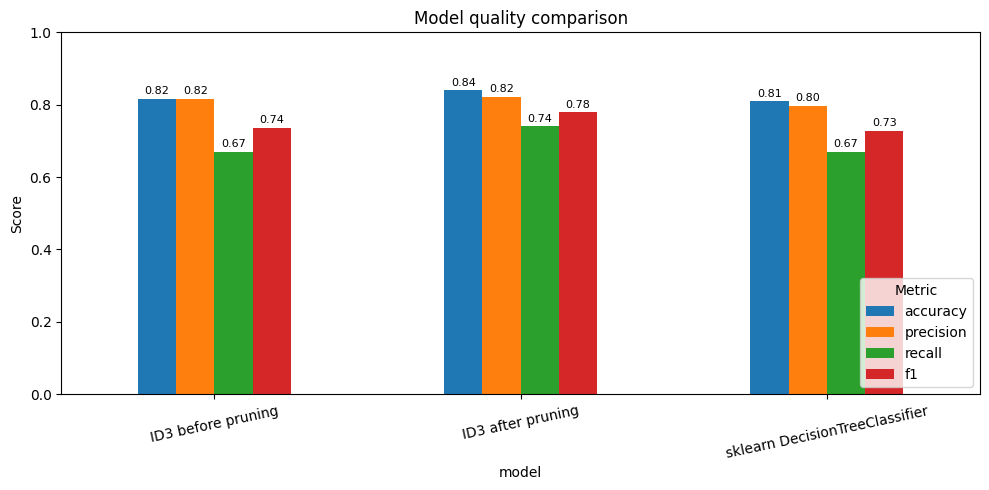

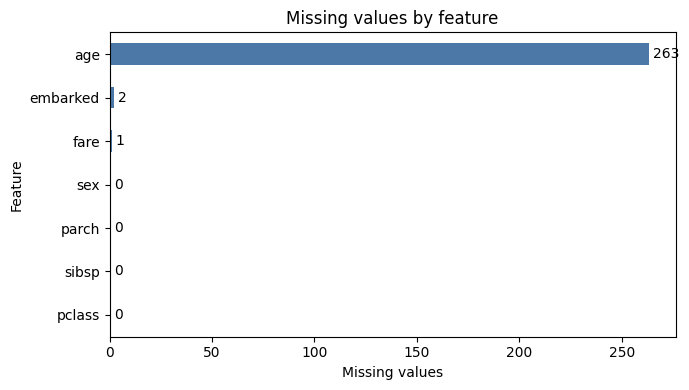

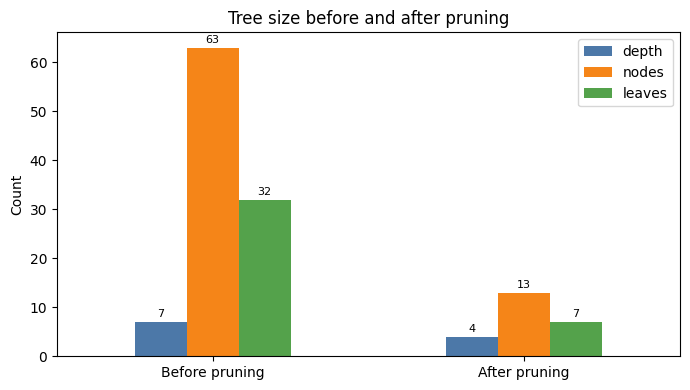

/var/folders/7p/6t1blt4s0xl1bw7577hyt8340000gn/T/ipykernel_40614/2874223288.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


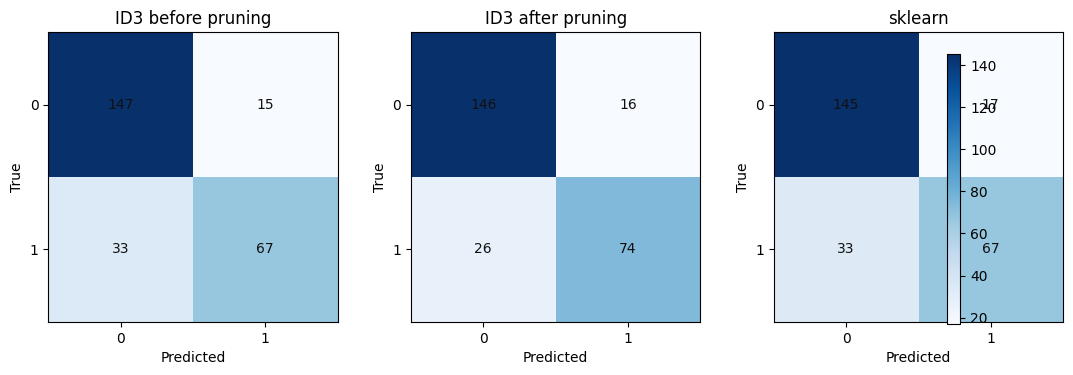

In [18]:
metric_columns = ["accuracy", "precision", "recall", "f1"]

fig, ax = plt.subplots(figsize=(10, 5))
metrics.set_index("model")[metric_columns].plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model quality comparison")
ax.legend(title="Metric", loc="lower right")
ax.tick_params(axis="x", rotation=12)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "metrics_comparison.svg", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
missing_values.sort_values("missing_count").plot(kind="barh", ax=ax, legend=False, color="#4C78A8")
ax.set_xlabel("Missing values")
ax.set_ylabel("Feature")
ax.set_title("Missing values by feature")
for index, value in enumerate(missing_values.sort_values("missing_count")["missing_count"]):
    ax.text(value + 2, index, str(value), va="center")
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "missing_values.svg", bbox_inches="tight")
plt.show()

tree_stats = pd.DataFrame(
    [before_stats, after_stats],
    index=["Before pruning", "After pruning"],
)
fig, ax = plt.subplots(figsize=(7, 4))
tree_stats.plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_ylabel("Count")
ax.set_title("Tree size before and after pruning")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8, padding=2)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "tree_reduction.svg", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
plot_titles = {
    "id3_before_pruning": "ID3 before pruning",
    "id3_after_pruning": "ID3 after pruning",
    "sklearn": "sklearn",
}
for ax, (name, matrix) in zip(axes, confusion_matrices.items()):
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(plot_titles[name])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, int(matrix[row, col]), ha="center", va="center", color="#111111")
fig.colorbar(image, ax=axes, fraction=0.025, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "confusion_matrices.svg", bbox_inches="tight")
plt.show()

## Вывод

Ноутбук выполняет все пункты эксперимента: обучает собственное дерево ID3 с критерием Джини, обрабатывает пропуски вероятностно, применяет редукцию дерева и сравнивает качество с эталонной реализацией sklearn.